# Forecast Validation

This notebook validates the batch wind forecast outputs produced in Layer 10.

Validation goals:

- Load the latest forecast run from S3
- Verify forecast schema completeness
- Check required non-null fields
- Inspect forecast prediction distributions
- Confirm forecast values are physically sane
- Compare forecasts against actual next-day wind capacity factor values
- Confirm outputs are presentation-ready

In [1]:
import os
import sys
from pathlib import Path

import yaml
from pyspark.sql import functions as F

# Find project root automatically
project_root = Path.cwd()
while not (project_root / "configs").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

print("Project root:", project_root)
os.chdir(project_root)

Project root: /home/ubuntu/renewable-energy-forecasting-pipeline


In [2]:
from pyspark.sql import functions as F

from src.common.spark_utils import get_spark_session
from src.reporting.export_metrics import resolve_path

spark = get_spark_session()

spark

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-4bebf291-e6fa-4f56-aaf9-c7d575320306;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 352ms :: artifacts dl 13ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	--------------------------------

## 1. Locate Latest Forecast Run

Forecast outputs are versioned by run ID under the configured forecast output path.

The notebook does not hardcode bucket names or run IDs. It resolves the forecast output location from project config and then selects the latest `run_id=...` directory.

In [3]:
def latest_forecast_run_path(spark):
    forecast_base = resolve_path("forecasts", "outputs")

    hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
    fs = spark.sparkContext._jvm.org.apache.hadoop.fs.FileSystem.get(
        spark.sparkContext._jvm.java.net.URI.create(forecast_base),
        hadoop_conf,
    )
    base_path = spark.sparkContext._jvm.org.apache.hadoop.fs.Path(forecast_base)

    statuses = fs.listStatus(base_path)

    run_paths = [
        status.getPath().toString()
        for status in statuses
        if status.isDirectory()
        and status.getPath().getName().startswith("run_id=")
        and not status.getPath().getName().endswith("_metadata")
    ]

    if not run_paths:
        raise FileNotFoundError(f"No forecast run_id folders found under {forecast_base}")

    return sorted(run_paths)[-1]


forecast_run_path = latest_forecast_run_path(spark)

forecast_run_path

26/05/04 09:15:16 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


's3a://syed-datsbd-s2026/forecasts/outputs/run_id=20260504T090915Z'

## 2. Load Forecast Outputs

The forecast table should contain one row per forecast date, state, target, and model version.

In [4]:
forecast_df = spark.read.parquet(forecast_run_path)

forecast_df.printSchema()
forecast_df.show(10, truncate=False)

root
 |-- forecast_id: string (nullable = true)
 |-- forecast_date: date (nullable = true)
 |-- region: string (nullable = true)
 |-- state: string (nullable = true)
 |-- target_name: string (nullable = true)
 |-- prediction: double (nullable = true)
 |-- model_name: string (nullable = true)
 |-- generation_timestamp: timestamp (nullable = true)
 |-- horizon_days: integer (nullable = true)
 |-- model_version: string (nullable = true)



+------------------------------------+-------------+------+-----+-------------------------------------+--------------------+---------------+--------------------------+------------+--------------------------------+
|forecast_id                         |forecast_date|region|state|target_name                          |prediction          |model_name     |generation_timestamp      |horizon_days|model_version                   |
+------------------------------------+-------------+------+-----+-------------------------------------+--------------------+---------------+--------------------------+------------+--------------------------------+
|825fb640-321e-427d-a0ad-156b9b1fec8b|2012-04-01   |NULL  |WY   |next_day_daily_region_capacity_factor|0.13047115566330833 |final_tuned_gbt|2026-05-04 09:10:09.932346|1           |final_tuned_gbt_20260504T063157Z|
|717145e7-52c3-4521-a97b-668aa06e11ba|2006-03-31   |NULL  |WY   |next_day_daily_region_capacity_factor|0.10753528266286255 |final_tuned_gbt|2026

## 3. Forecast Coverage Checks

This section checks the number of forecast rows, forecast dates, states, targets, and model versions.

In [5]:
coverage_summary = forecast_df.agg(
    F.count("*").alias("row_count"),
    F.countDistinct("forecast_date").alias("forecast_dates"),
    F.countDistinct("state").alias("states"),
    F.countDistinct("target_name").alias("targets"),
    F.countDistinct("model_name").alias("models"),
    F.countDistinct("model_version").alias("model_versions"),
)

coverage_summary.show(truncate=False)

+---------+--------------+------+-------+------+--------------+
|row_count|forecast_dates|states|targets|models|model_versions|
+---------+--------------+------+-------+------+--------------+
|535961   |11167         |48    |1      |1     |1             |
+---------+--------------+------+-------+------+--------------+



In [6]:
forecast_df.groupBy("model_name", "model_version", "target_name", "horizon_days").agg(
    F.count("*").alias("rows"),
    F.min("forecast_date").alias("min_forecast_date"),
    F.max("forecast_date").alias("max_forecast_date"),
    F.countDistinct("state").alias("states"),
).show(truncate=False)

+---------------+--------------------------------+-------------------------------------+------------+------+-----------------+-----------------+------+
|model_name     |model_version                   |target_name                          |horizon_days|rows  |min_forecast_date|max_forecast_date|states|
+---------------+--------------------------------+-------------------------------------+------------+------+-----------------+-----------------+------+
|final_tuned_gbt|final_tuned_gbt_20260504T063157Z|next_day_daily_region_capacity_factor|1           |535961|1995-01-31       |2025-08-27       |48    |
+---------------+--------------------------------+-------------------------------------+------------+------+-----------------+-----------------+------+



## 4. Schema Completeness Check

The forecast output should match the Layer 10 forecast schema contract.

In [7]:
required_columns = [
    "forecast_id",
    "forecast_date",
    "region",
    "state",
    "target_name",
    "prediction",
    "model_name",
    "model_version",
    "generation_timestamp",
    "horizon_days",
]

missing_columns = [c for c in required_columns if c not in forecast_df.columns]

if missing_columns:
    raise ValueError(f"Missing required forecast columns: {missing_columns}")

print("Schema completeness check passed.")

Schema completeness check passed.


## 5. Required Non-Null Checks

The `region` field is allowed to be null because the current forecast grain is state-level.

In [8]:
required_non_null_columns = [
    "forecast_id",
    "forecast_date",
    "state",
    "target_name",
    "prediction",
    "model_name",
    "model_version",
    "generation_timestamp",
    "horizon_days",
]

null_summary = forecast_df.select(
    *[
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in required_non_null_columns
    ]
)

null_summary.show(truncate=False)

+-----------+-------------+-----+-----------+----------+----------+-------------+--------------------+------------+
|forecast_id|forecast_date|state|target_name|prediction|model_name|model_version|generation_timestamp|horizon_days|
+-----------+-------------+-----+-----------+----------+----------+-------------+--------------------+------------+
|0          |0            |0    |0          |0         |0         |0            |0                   |0           |
+-----------+-------------+-----+-----------+----------+----------+-------------+--------------------+------------+



In [9]:
null_counts = null_summary.collect()[0].asDict()
bad_nulls = {k: v for k, v in null_counts.items() if v > 0}

if bad_nulls:
    raise ValueError(f"Unexpected nulls found: {bad_nulls}")

print("Required non-null check passed.")

Required non-null check passed.


## 6. Forecast Distribution Summary

Predictions represent next-day regional/state wind capacity factor. Values should generally be bounded between 0 and 1.

In [10]:
prediction_summary = forecast_df.agg(
    F.min("prediction").alias("min_prediction"),
    F.expr("percentile_approx(prediction, 0.01)").alias("p01"),
    F.expr("percentile_approx(prediction, 0.05)").alias("p05"),
    F.expr("percentile_approx(prediction, 0.25)").alias("p25"),
    F.expr("percentile_approx(prediction, 0.50)").alias("median"),
    F.expr("percentile_approx(prediction, 0.75)").alias("p75"),
    F.expr("percentile_approx(prediction, 0.95)").alias("p95"),
    F.expr("percentile_approx(prediction, 0.99)").alias("p99"),
    F.max("prediction").alias("max_prediction"),
    F.avg("prediction").alias("avg_prediction"),
    F.stddev("prediction").alias("std_prediction"),
)

prediction_summary.show(truncate=False)

+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|min_prediction      |p01                 |p05                 |p25                 |median             |p75                |p95                |p99                |max_prediction     |avg_prediction     |std_prediction     |
+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|7.606317356794578E-4|0.004751909636246405|0.007332417021446748|0.018953982546752363|0.03434829764243652|0.05585685982152555|0.10957813014476017|0.15663229831031492|0.46409183463197246|0.04279248745242175|0.03335431427718071|
+--------------------+--------------------+--------------------+--------------------+-----------

## 7. Physical Sanity Check

Capacity factor predictions should not be negative and should not exceed 1.

In [11]:
invalid_prediction_df = forecast_df.filter(
    (F.col("prediction") < 0) | (F.col("prediction") > 1)
)

invalid_count = invalid_prediction_df.count()

print(f"Invalid prediction count: {invalid_count}")

invalid_prediction_df.show(20, truncate=False)

Invalid prediction count: 0


+-----------+-------------+------+-----+-----------+----------+----------+--------------------+------------+-------------+
|forecast_id|forecast_date|region|state|target_name|prediction|model_name|generation_timestamp|horizon_days|model_version|
+-----------+-------------+------+-----+-----------+----------+----------+--------------------+------------+-------------+
+-----------+-------------+------+-----+-----------+----------+----------+--------------------+------------+-------------+



In [13]:
if invalid_count > 0:
    raise ValueError("Forecast output contains predictions outside the expected [0, 1] range.")

print("Prediction range check passed.")

Prediction range check passed.


## 8. State-Level Forecast Distribution

This section checks whether any states have unusual forecast distributions.

In [14]:
state_prediction_summary = forecast_df.groupBy("state").agg(
    F.count("*").alias("rows"),
    F.min("prediction").alias("min_prediction"),
    F.avg("prediction").alias("avg_prediction"),
    F.max("prediction").alias("max_prediction"),
    F.stddev("prediction").alias("std_prediction"),
).orderBy("avg_prediction", ascending=False)

state_prediction_summary.show(60, truncate=False)

+-----+-----+---------------------+--------------------+-------------------+--------------------+
|state|rows |min_prediction       |avg_prediction      |max_prediction     |std_prediction      |
+-----+-----+---------------------+--------------------+-------------------+--------------------+
|ND   |11166|0.011278447675835048 |0.09039468849886523 |0.35289835516982526|0.04591491141011282 |
|SD   |11166|0.013707431937647101 |0.0901775214615495  |0.46409183463197246|0.045186392546350596|
|KS   |11166|0.013084029395671206 |0.08393096964878981 |0.35515991925157686|0.04307912373039667 |
|NE   |11166|0.012103249879959577 |0.07915416437101903 |0.3804534146839656 |0.04279823442347294 |
|MT   |11166|0.015628557191135838 |0.0784089955301247  |0.2851264877388197 |0.036305359914385577|
|WY   |11166|0.014417531288202409 |0.07719860407972808 |0.25909540822185606|0.03661109933726797 |
|NM   |11166|0.01463222139110371  |0.07219919861080341 |0.26766545417083204|0.03806218452946817 |
|IA   |11166|0.00617

## 9. Load Actual Target Values

The actual comparison uses the Layer 8 feature table, where the target column is:

`next_day_daily_region_capacity_factor`

Forecasts are joined to actuals by:

- forecast date
- state

In [15]:
features_path = resolve_path("gold", "wind_ml_features")

features_df = spark.read.parquet(features_path)

features_df.select(
    "date_utc",
    "state",
    "next_day_daily_region_capacity_factor"
).show(10, truncate=False)

+----------+-----+-------------------------------------+
|date_utc  |state|next_day_daily_region_capacity_factor|
+----------+-----+-------------------------------------+
|1995-01-01|CA   |0.016321                             |
|1995-01-02|CA   |0.034959                             |
|1995-01-03|CA   |0.105512                             |
|1995-01-04|CA   |0.161117                             |
|1995-01-05|CA   |0.050008                             |
|1995-01-06|CA   |0.151811                             |
|1995-01-07|CA   |0.127293                             |
|1995-01-08|CA   |0.165392                             |
|1995-01-09|CA   |0.148839                             |
|1995-01-10|CA   |0.083149                             |
+----------+-----+-------------------------------------+
only showing top 10 rows



In [16]:
actuals_df = features_df.select(
    F.col("date_utc").cast("date").alias("forecast_date"),
    F.col("state"),
    F.col("next_day_daily_region_capacity_factor").alias("actual"),
)

actuals_df.show(10, truncate=False)

+-------------+-----+--------+
|forecast_date|state|actual  |
+-------------+-----+--------+
|1995-01-01   |CA   |0.016321|
|1995-01-02   |CA   |0.034959|
|1995-01-03   |CA   |0.105512|
|1995-01-04   |CA   |0.161117|
|1995-01-05   |CA   |0.050008|
|1995-01-06   |CA   |0.151811|
|1995-01-07   |CA   |0.127293|
|1995-01-08   |CA   |0.165392|
|1995-01-09   |CA   |0.148839|
|1995-01-10   |CA   |0.083149|
+-------------+-----+--------+
only showing top 10 rows



In [17]:
actuals_df = features_df.select(
    F.col("date_utc").cast("date").alias("forecast_date"),
    F.col("state"),
    F.col("next_day_daily_region_capacity_factor").alias("actual"),
)

actuals_df.show(10, truncate=False)

+-------------+-----+--------+
|forecast_date|state|actual  |
+-------------+-----+--------+
|1995-01-01   |CA   |0.016321|
|1995-01-02   |CA   |0.034959|
|1995-01-03   |CA   |0.105512|
|1995-01-04   |CA   |0.161117|
|1995-01-05   |CA   |0.050008|
|1995-01-06   |CA   |0.151811|
|1995-01-07   |CA   |0.127293|
|1995-01-08   |CA   |0.165392|
|1995-01-09   |CA   |0.148839|
|1995-01-10   |CA   |0.083149|
+-------------+-----+--------+
only showing top 10 rows



## 10. Forecast vs Actual Comparison

This validates that forecast outputs can be compared against known target values.

In [18]:
comparison_df = (
    forecast_df.select(
        "forecast_date",
        "state",
        "prediction",
        "model_name",
        "model_version",
    )
    .join(actuals_df, on=["forecast_date", "state"], how="inner")
)

comparison_df.show(10, truncate=False)

+-------------+-----+--------------------+---------------+--------------------------------+--------+
|forecast_date|state|prediction          |model_name     |model_version                   |actual  |
+-------------+-----+--------------------+---------------+--------------------------------+--------+
|1995-01-31   |DE   |0.04968853812170471 |final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.015846|
|1995-01-31   |GA   |0.023265414754090826|final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.037139|
|1995-01-31   |IA   |0.062204585012914176|final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.010925|
|1995-01-31   |LA   |0.03429443730584293 |final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.022171|
|1995-01-31   |NE   |0.08233301351219992 |final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.08429 |
|1995-02-01   |LA   |0.0637891890686638  |final_tuned_gbt|final_tuned_gbt_20260504T063157Z|0.009455|
|1995-02-01   |NV   |0.05303254335183637 |final_tuned_gbt|final_tuned_gbt_20260504T063157Z|

In [19]:
comparison_counts = comparison_df.agg(
    F.count("*").alias("comparison_rows"),
    F.countDistinct("forecast_date").alias("forecast_dates"),
    F.countDistinct("state").alias("states"),
)

comparison_counts.show(truncate=False)

+---------------+--------------+------+
|comparison_rows|forecast_dates|states|
+---------------+--------------+------+
|535961         |11167         |48    |
+---------------+--------------+------+



## 11. Error Metrics

This section computes simple forecast error metrics against actual next-day capacity factor.

In [20]:
comparison_df = comparison_df.withColumn(
    "error",
    F.col("prediction") - F.col("actual")
).withColumn(
    "absolute_error",
    F.abs(F.col("error"))
).withColumn(
    "squared_error",
    F.pow(F.col("error"), 2)
)

error_summary = comparison_df.agg(
    F.count("*").alias("rows"),
    F.avg("absolute_error").alias("mae"),
    F.sqrt(F.avg("squared_error")).alias("rmse"),
    F.avg("prediction").alias("avg_prediction"),
    F.avg("actual").alias("avg_actual"),
    F.avg("error").alias("bias"),
)

error_summary.show(truncate=False)

+------+--------------------+--------------------+-------------------+--------------------+---------------------+
|rows  |mae                 |rmse                |avg_prediction     |avg_actual          |bias                 |
+------+--------------------+--------------------+-------------------+--------------------+---------------------+
|535961|0.027492149006163574|0.045528625785710486|0.04279248745242152|0.042578233160622016|2.1425429179996395E-4|
+------+--------------------+--------------------+-------------------+--------------------+---------------------+



## 12. State-Level Error Review

This highlights states where forecasts are less accurate.

In [21]:
state_error_summary = comparison_df.groupBy("state").agg(
    F.count("*").alias("rows"),
    F.avg("prediction").alias("avg_prediction"),
    F.avg("actual").alias("avg_actual"),
    F.avg("absolute_error").alias("mae"),
    F.sqrt(F.avg("squared_error")).alias("rmse"),
    F.avg("error").alias("bias"),
).orderBy("mae", ascending=False)

state_error_summary.show(60, truncate=False)

+-----+-----+--------------------+--------------------+--------------------+--------------------+----------------------+
|state|rows |avg_prediction      |avg_actual          |mae                 |rmse                |bias                  |
+-----+-----+--------------------+--------------------+--------------------+--------------------+----------------------+
|ND   |11166|0.09039468849886519 |0.09225018395128064 |0.06123728017098483 |0.09122588067660843 |-0.0018554954524154434|
|SD   |11166|0.09017752146154978 |0.08910311346946093 |0.05859121921691374 |0.08581866915707301 |0.0010744079920886453 |
|KS   |11166|0.08393096964878992 |0.08387322353573329 |0.05229314904196221 |0.0751603283107025  |5.7746113056345684E-5 |
|NE   |11166|0.07915416437101898 |0.07845719407128801 |0.04896463293583392 |0.07386329616434469 |6.969702997311772E-4  |
|IA   |11166|0.06616054724969804 |0.06579301522478982 |0.04616137047612967 |0.07057298328123073 |3.675320249086684E-4  |
|MT   |11166|0.07840899553012468

## 13. Recent Forecast Review

This section shows the most recent forecast dates available in the output table.

In [22]:
forecast_df.orderBy(F.col("forecast_date").desc(), F.col("state")).show(50, truncate=False)

+------------------------------------+-------------+------+-----+-------------------------------------+---------------------+---------------+--------------------------+------------+--------------------------------+
|forecast_id                         |forecast_date|region|state|target_name                          |prediction           |model_name     |generation_timestamp      |horizon_days|model_version                   |
+------------------------------------+-------------+------+-----+-------------------------------------+---------------------+---------------+--------------------------+------------+--------------------------------+
|9338d933-170a-4971-9ba4-a352aed197d0|2025-08-27   |NULL  |AL   |next_day_daily_region_capacity_factor|0.004011272547682069 |final_tuned_gbt|2026-05-04 09:10:09.932346|1           |final_tuned_gbt_20260504T063157Z|
|ca057856-8313-4ef2-9fc5-6e123585369b|2025-08-26   |NULL  |AL   |next_day_daily_region_capacity_factor|0.004135637436196395 |final_tuned_gbt

## 14. Presentation-Ready Output Sample

This table is suitable for screenshots or summary reporting.

In [23]:
presentation_sample = (
    forecast_df.select(
        "forecast_date",
        "state",
        "target_name",
        F.round("prediction", 4).alias("predicted_capacity_factor"),
        "model_version",
        "generation_timestamp",
    )
    .orderBy(F.col("forecast_date").desc(), "state")
)

presentation_sample.show(25, truncate=False)

+-------------+-----+-------------------------------------+-------------------------+--------------------------------+--------------------------+
|forecast_date|state|target_name                          |predicted_capacity_factor|model_version                   |generation_timestamp      |
+-------------+-----+-------------------------------------+-------------------------+--------------------------------+--------------------------+
|2025-08-27   |AL   |next_day_daily_region_capacity_factor|0.004                    |final_tuned_gbt_20260504T063157Z|2026-05-04 09:10:09.932346|
|2025-08-26   |AL   |next_day_daily_region_capacity_factor|0.0041                   |final_tuned_gbt_20260504T063157Z|2026-05-04 09:10:09.932346|
|2025-08-26   |AR   |next_day_daily_region_capacity_factor|0.0046                   |final_tuned_gbt_20260504T063157Z|2026-05-04 09:10:09.932346|
|2025-08-26   |AZ   |next_day_daily_region_capacity_factor|0.056                    |final_tuned_gbt_20260504T063157Z|2026-0

## Validation Summary

Forecast validation checks completed:

- Forecast outputs load from the latest config-resolved run
- Schema contains all required forecast fields
- Required fields are non-null
- Predictions are bounded in the expected capacity factor range
- Forecast distributions are inspectable by state
- Forecasts can be joined to actual target values
- MAE and RMSE can be computed from generated forecasts
- Outputs are presentation-ready

Batch inference and forecast outputs are complete when this notebook runs successfully and `tests/test_model_io.py` passes.

In [24]:
import matplotlib.pyplot as plt

forecast_pd = forecast_df.select(
    "forecast_date", "state", "prediction"
).toPandas()

comparison_pd = comparison_df.select(
    "forecast_date", "state", "prediction", "actual"
).toPandas()

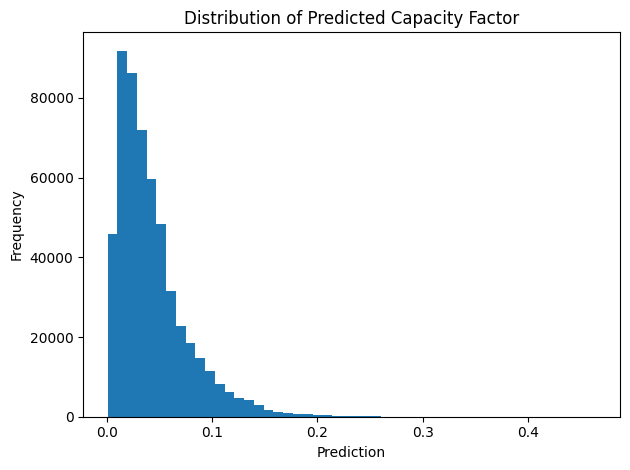

In [29]:
plt.figure()
plt.hist(forecast_pd["prediction"], bins=50)
plt.title("Distribution of Predicted Capacity Factor")
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Distribution of Predicted Capacity Factor

The distribution is highly right-skewed, with most predictions concentrated between ~0.01 and 0.08 and a long tail extending beyond 0.2. This reflects the physical reality of wind generation: low-to-moderate capacity factors are common, while high-output days are rare. The absence of negative values and reasonable upper bounds (~0.45) indicates the model is producing physically valid predictions.

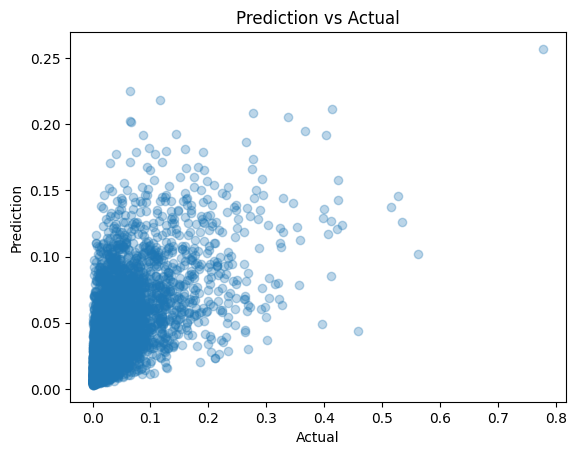

In [28]:
sample_pd = comparison_pd.sample(n=5000, random_state=42)

plt.figure()
plt.scatter(sample_pd["actual"], sample_pd["prediction"], alpha=0.3)
plt.title("Prediction vs Actual")
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.tight_layout
plt.show()

Prediction vs Actual

There is a clear positive relationship between predicted and actual values, confirming the model captures the underlying signal. However, the dispersion increases at higher actual values, indicating reduced accuracy during high-wind conditions. This suggests the model tends to underestimate extreme events and exhibits regression-to-the-mean behavior, which is typical for tree-based models trained on aggregated features.

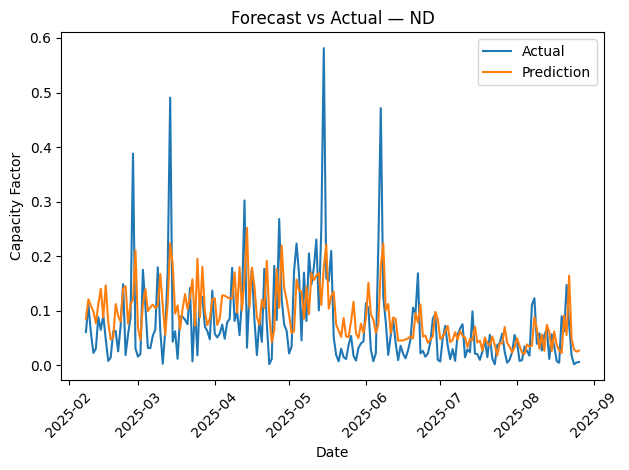

In [30]:
state = "ND" # Change this to view different states (Pick a strong wind state)

state_df = comparison_pd[comparison_pd["state"] == state].sort_values("forecast_date").tail(200)

plt.figure()
plt.plot(state_df["forecast_date"], state_df["actual"], label="Actual")
plt.plot(state_df["forecast_date"], state_df["prediction"], label="Prediction")
plt.title(f"Forecast vs Actual — {state}")
plt.xlabel("Date")
plt.ylabel("Capacity Factor")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Forecast vs Actual — ND

The model tracks the overall temporal pattern and seasonality in North Dakota, but consistently smooths sharp peaks and troughs. High spikes in actual capacity factor are often underpredicted, indicating limited sensitivity to sudden wind surges. This behavior reflects reliance on lagged and rolling features, which inherently dampen short-term volatility.

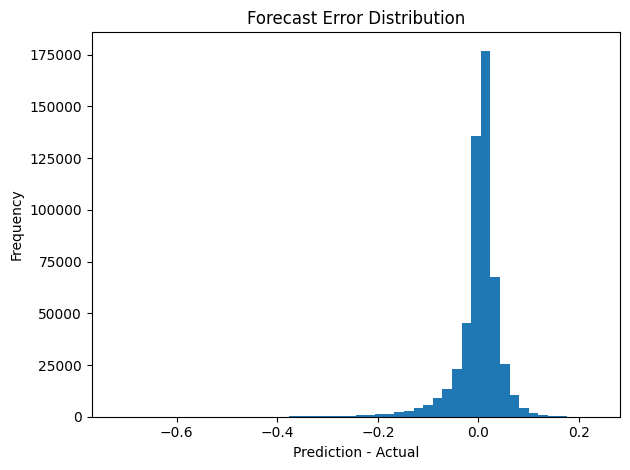

In [32]:
comparison_pd["error"] = comparison_pd["prediction"] - comparison_pd["actual"]

plt.figure()
plt.hist(comparison_pd["error"], bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Prediction - Actual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Forecast Error Distribution

The error distribution is centered near zero, confirming minimal systematic bias across the dataset. The distribution is slightly left-skewed, indicating a tendency to underpredict during high-capacity events. Most errors fall within a narrow range, showing stable performance, while extreme errors correspond to rare high-wind days.

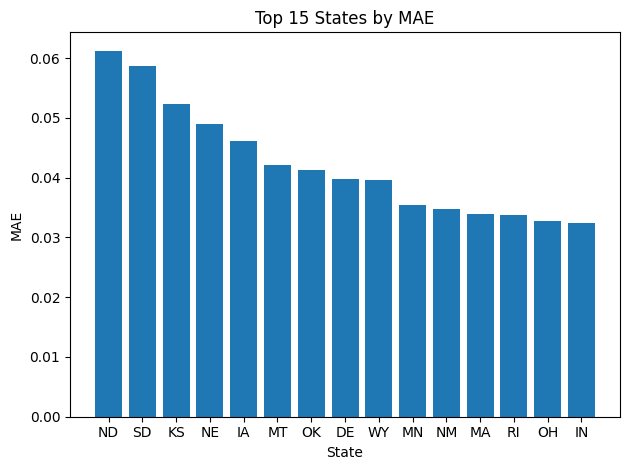

In [33]:
state_error_pd = state_error_summary.toPandas().sort_values("mae", ascending=False).head(15)

plt.figure()
plt.bar(state_error_pd["state"], state_error_pd["mae"])
plt.title("Top 15 States by MAE")
plt.xlabel("State")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

Top 15 States by MAE

States with the highest MAE (ND, SD, KS, NE) are known for strong and highly variable wind patterns. Higher error in these regions reflects increased volatility rather than model failure. Lower-wind states show smaller errors, as their capacity factors are more stable and easier to predict.

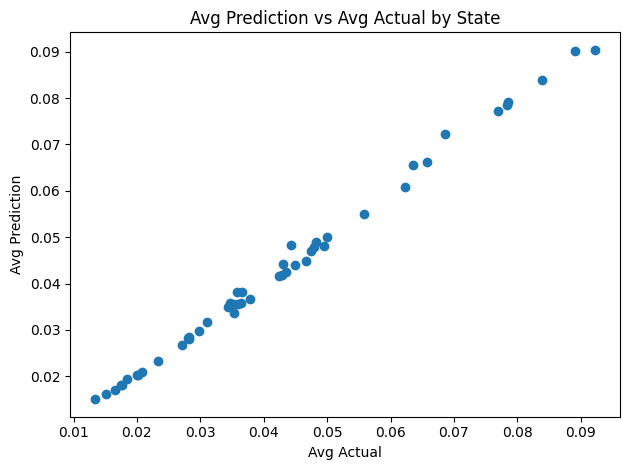

In [35]:
state_error_pd_full = state_error_summary.toPandas()

plt.figure()
plt.scatter(
    state_error_pd_full["avg_actual"],
    state_error_pd_full["avg_prediction"]
)
plt.title("Avg Prediction vs Avg Actual by State")
plt.xlabel("Avg Actual")
plt.ylabel("Avg Prediction")
plt.tight_layout()
plt.show()

Avg Prediction vs Avg Actual by State

The near-perfect diagonal alignment indicates strong calibration at the aggregate level. The model accurately preserves relative differences in wind potential across states, with minimal bias. This confirms that while point-wise errors exist, the model is well-calibrated in expectation, which is critical for planning and aggregation use cases.

In [36]:
spark.stop()